<a href="https://colab.research.google.com/github/mauriciodev/tec_forecast/blob/main/examples/OpenSTL_GIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenSTL Tutorial with Ionosphere data

In this notebook, we will provide an example on how to use OpenSTL library with Global Ionosphere Maps data.



# Setup the environment

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!git clone https://github.com/chengtan9907/OpenSTL

Cloning into 'OpenSTL'...
remote: Enumerating objects: 2619, done.
remote: Counting objects: 100% (1126/1126), done.
remote: Compressing objects: 100% (302/302), done.
remote: Total 2619 (delta 937), reused 855 (delta 823), pack-reused 1493 (from 1)
Receiving objects: 100% (2619/2619), 3.02 MiB | 4.89 MiB/s, done.
Resolving deltas: 100% (1875/1875), done.


In [3]:
!pip install fvcore
!pip install -e OpenSTL
#!python setup.py install
os.chdir('/content/OpenSTL')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61395 sha256=3c9223549e081024927306e79c9a8af5b9668635118f307553a01f5509fe1938
  Stored in directory: /root/.cache/pip/wheels/01/c0/af/77c1cf53a1be9e42a52b48e5af2169d40ec2e89f7362489dd0
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31529 sha256=1676ec94cee6a43b0ab462aeddc4a8840ef5b4048c66e0ff691789b65002af74
  Stored in directory: /root/.cache/pip/wheels/9a/a3/b6/ac0fcd1b4ed5cfeb3db92e6a0e476cfd48ed0df92b91080c1d
Successfully built fvcore iopath
Obtaining file:///content/OpenSTL
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# hyperparameters

`pre_seq_length`: the number of given frames

`aft_seq_length`: the number of frames to predict

In [4]:
pre_seq_length = 36
aft_seq_length = 12
stride = 12
batch_size = 8
epochs = 1 #00

# Downloading Global Ionosphere Maps (GIM) data

In [5]:
#downloading data from tec_forecast
!gdown 1vUnBk8SIl-ieiDpKR-Mv9Vhua2566eAd

Downloading...
From: https://drive.google.com/uc?id=1vUnBk8SIl-ieiDpKR-Mv9Vhua2566eAd
To: /content/OpenSTL/codg_14-15.h5
100% 70.6M/70.6M [00:02<00:00, 33.6MB/s]


In [6]:
import h5py
import numpy as np
f = h5py.File('codg_14-15.h5', 'r')
train_npy=np.array(f['2014']) #Train/val
train_npy = np.concatenate((train_npy[:,:,:-1,:],train_npy[:,-1:,:-1,:]),axis=1)
train_npy=np.moveaxis(train_npy, [1, 2, 3], [2,3 ,1]) #T, C, H, W

test_npy=np.array(f['2015']) #Test data
test_npy = np.concatenate((test_npy[:,:,:-1,:],test_npy[:,-1:,:-1,:]),axis=1)
test_npy=np.moveaxis(test_npy, [1, 2, 3], [2,3 ,1]) #T, C, H, W

f.close()
print("Training data:", train_npy.shape)
print("Testing data:", test_npy.shape)

Training data: (4380, 1, 72, 72)
Testing data: (4380, 1, 72, 72)


## Data exploration

(array([8.824254e+06, 7.900799e+06, 3.129145e+06, 1.446079e+06,
        7.742670e+05, 4.324150e+05, 1.621500e+05, 3.352500e+04,
        3.125000e+03, 1.610000e+02]),
 array([  0.  ,  15.58,  31.16,  46.74,  62.32,  77.9 ,  93.48, 109.06,
        124.64, 140.22, 155.8 ]),
 <BarContainer object of 10 artists>)

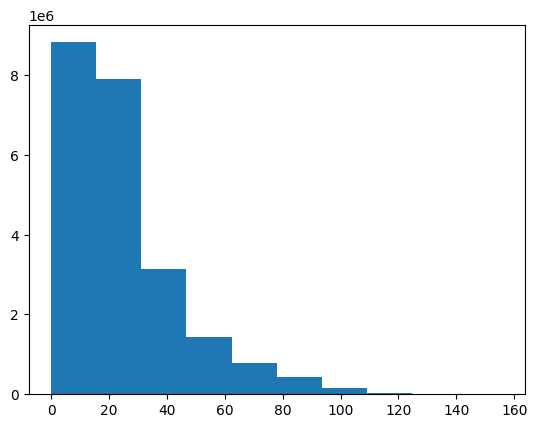

In [7]:
plt.hist(train_npy.reshape((-1)))

## Visualize an example

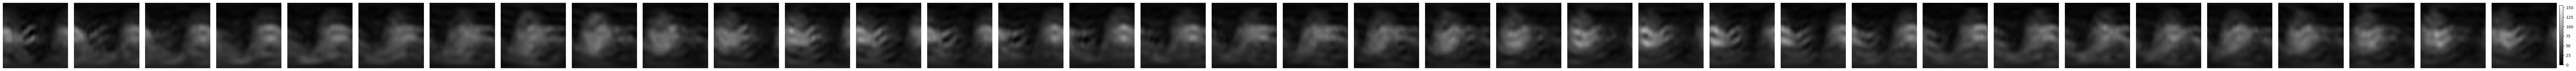

In [27]:
from openstl.utils import show_video_line

# show the given frames from an example
example_idx = 0
vmax=train_npy.max()
show_video_line(train_npy[example_idx:example_idx+pre_seq_length], ncols=pre_seq_length, vmax=vmax, cbar=True, out_path=None, format='png', use_rgb=False)

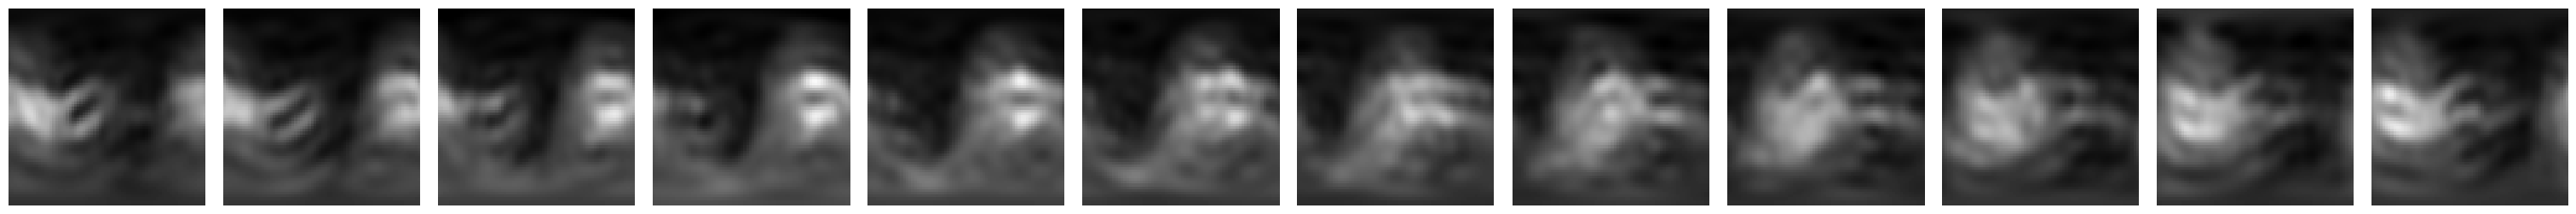

In [28]:
# show the future frames from an example
example_idx = 0
vmax=100
show_video_line(train_npy[example_idx+pre_seq_length:example_idx+pre_seq_length+aft_seq_length], ncols=aft_seq_length, vmax=vmax, cbar=False, out_path=None, format='png', use_rgb=False)

###
Torch dataset
This class is responsible for the Sliding Window time sampling and splitting the training/validation sets.

In [15]:
import torch
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import train_test_split
class ionexDataset(Dataset):
    def __init__(self, npy_data, nstepsin=36, nstepsout=12, stride=12, val_split=0.2, validation_set=False, random_state=1 ):
        self.data = npy_data.astype(np.float32)
        self.nstepsin=nstepsin
        self.nstepsout=nstepsout
        self.stride=stride
        self.data_name = 'ionex'
        #store the index to allow shuffling and train/val split
        self.idx=np.arange(0,len(self.data)-nstepsout-nstepsin+1,stride)

        if val_split>0:
            datasplit=train_test_split(self.idx,random_state=random_state, test_size=val_split)
            if validation_set==False: #training set
                self.idx=datasplit[0]
            else: #validation set
                self.idx=datasplit[1]

        #if normalize:
        # get the mean/std values along the channel dimension
        mean = self.data.mean(axis=(0, 1, 2, 3)).reshape(1, -1, 1, 1)
        std = self.data.std(axis=(0, 1, 2, 3)).reshape(1, -1, 1, 1)
        self.data = (self.data - mean) / std
        self.mean = mean
        self.std = std


    def __getitem__(self, index):
        # find the end of this pattern
        i=self.idx[index]
        end_ix = i + self.nstepsin
        # check if we are beyond the sequence
        if end_ix + self.nstepsout> len(self.data):
            return None,None
        # gather input and output parts of the pattern
        seq_x, seq_y = self.data[i:end_ix], self.data[end_ix:end_ix+self.nstepsout]
        return seq_x,seq_y

    def __len__(self):
        return len(self.idx)

    #def split_train_val(self, val_split=0.25):
    #    train_idx, val_idx = train_test_split(list(range(len(self))), test_size=val_split)
    #    return Subset(self, train_idx), Subset(self, val_idx)

In [16]:
train_data = ionexDataset(train_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length,
                         stride=stride, validation_set=False, val_split=0.2)
val_data = ionexDataset(train_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length,
                         stride=stride, validation_set=True, val_split=0.2)
#train_data, val_data = ionexTrainData.split_train_val(val_split=0.2)
dataloader_train = DataLoader(train_data, batch_size=batch_size, num_workers=os.cpu_count())
dataloader_val = DataLoader(val_data, batch_size=batch_size, num_workers=os.cpu_count())

ionexTestData = ionexDataset(test_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length, stride=stride)
dataloader_test = DataLoader(ionexTestData, batch_size=batch_size, num_workers=os.cpu_count())

for X, y in dataloader_train:
    print(f"Shape of X: {X.shape} {X.dtype} [N, C, H, W]")
    print(f"Shape of Y: {y.shape} {y.dtype}")
    break
print(f"Training samples: {len(dataloader_train.dataset)}")
print(f"Validation samples: {len(dataloader_val.dataset)}")
in_shape=X.shape[1:]
print(in_shape)

Shape of X: torch.Size([8, 36, 1, 72, 72]) torch.float32 [N, C, H, W]
Shape of Y: torch.Size([8, 12, 1, 72, 72]) torch.float32
Training samples: 289
Validation samples: 73
torch.Size([36, 1, 72, 72])


# Train and evaluate

## (IMPORTANT) Define the custom configs

We first define the training configuration, which includes several important hyperparameters for training.

Here, we set `epoch = 3` as an example for simple training. The actual value of epoch in your project depends on the complexity of your dataset. Generally, a good starting point is `epoch = 100`.

Next, we define the model configuration to customize a spatio-temporal predictive learning model. For MetaVP models, the key hyperparameters are: `N_S`, `N_T`, `hid_S`, `hid_T`, and `model_type`. Users have the option to either use a config file or directly set these hyperparameters.

If a config file is preferred, the user can simply include a `config_file` key with the path to the config file in the `custom_model_config` below. Otherwise, the user can directly specify these hyperparameters in the `custom_model_config`.

In [17]:
custom_training_config = {
    'pre_seq_length': pre_seq_length,
    'aft_seq_length': aft_seq_length,
    'total_length': pre_seq_length + aft_seq_length,
    'batch_size': batch_size,
    'val_batch_size': batch_size,
    'epoch': epochs, #100,
    'sched': 'onecycle',
    'lr': 0.001,
    'metrics': ['mae', 'mse'],
    'opt': 'adam',

    'ex_name': 'custom_exp',
    'dataname': 'custom',
    'in_shape': in_shape, #[10, 3, 32, 32],
    #'use_gpu': False
}

custom_model_config = {
    # For MetaVP models, the most important hyperparameters are:
    # N_S, N_T, hid_S, hid_T, model_type
    'method': 'ConvLSTM', #'SimVP', ####### This is the prediction method #######

    # Users can either using a config file or directly set these hyperparameters
    # 'config_file': 'configs/custom/example_model.py',

    # Here, we directly set these parameters
    'model_type': 'None', #'gSTA', ####### This is the model ####### #ViT
    'N_S': 4,
    'N_T': 8,
    'hid_S': 64,
    'hid_T': 256
}


import configs.mmnist.ConvLSTM as mod

custom_model_config = dict(
    filter(
        lambda x: not x[0].startswith('__'),
        mod.__dict__.items()
        )
    )



In [18]:
custom_model_config

{'method': 'ConvLSTM',
 'reverse_scheduled_sampling': 0,
 'r_sampling_step_1': 25000,
 'r_sampling_step_2': 50000,
 'r_exp_alpha': 5000,
 'scheduled_sampling': 1,
 'sampling_stop_iter': 50000,
 'sampling_start_value': 1.0,
 'sampling_changing_rate': 2e-05,
 'num_hidden': '128,128,128,128',
 'filter_size': 5,
 'stride': 1,
 'patch_size': 4,
 'layer_norm': 0,
 'lr': 0.0005,
 'batch_size': 16,
 'sched': 'onecycle'}

## Setup the experiment

We retrieve the default hyperparameters by utilizing `create_parser` and update those hyperparameters that are defined in `custom_training_config` and `custom_model_config`.

By utilizing `BaseExperiment`, we ensure that everything is prepared, including dataloader setup and model initialization.

In [19]:
from openstl.api import BaseExperiment
from openstl.utils import create_parser, default_parser

args = create_parser().parse_args([])
config = args.__dict__

# update the training config
config.update(custom_training_config)
# update the model config
config.update(custom_model_config)

exp = BaseExperiment(args, dataloaders=(dataloader_train, dataloader_val, dataloader_test))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


## Start training and evaluation

With everything in place, we are now ready to start training and evaluation.

Here we go!

In [20]:
print('>'*35 + ' training ' + '<'*35)
exp.train()

print('>'*35 + ' testing  ' + '<'*35)
exp.test()

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> training <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type           | Params
---------------------------------------------
0 | model     | ConvLSTM_Model | 15.1 M
1 | criterion | MSELoss        | 0     
---------------------------------------------
15.1 M    Trainable params
0         Non-trainable params
15.1 M    Total params
60.334    Total estimated model params size (MB)


Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.10.12 (main, Jul 29 2024, 16:56:48) [GCC 11.4.0]
CUDA available: True
CUDA_HOME: /usr/local/cuda
NVCC: Build cuda_12.2.r12.2/compiler.33191640_0
GPU 0: Tesla T4
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
PyTorch: 2.3.1+cu121
PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.6 (Git Hash 86e6af5974177e513fd3fee58425e1063e7f1361)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencod

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 37: 'val_loss' reached 0.54052 (best 0.54052), saving model to '/content/OpenSTL/work_dirs/custom_exp/checkpoints/best-epoch=00-val_loss=0.541.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> testing  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


Testing: |          | 0/? [00:00<?, ?it/s]

mse:751768.5625, mae:44007.546875


# Saving to Google Drive

In [24]:
from google.colab import drive
drive.mount('/content/drive')
outdir = "/content/drive/MyDrive/openstl"
!echo Saving experiment to {outdir}
!mkdir -p {outdir}
!cp ./work_dirs/custom_exp/saved/ {outdir}/saved -R

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving experiment to /content/drive/MyDrive/openstl


## Visualization

By employing the `show_video_line` and `show_video_gif_multiple` functions provided by `OpenSTL`, we can visualize the input, ground truth, and predicted frames, as well as generate corresponding GIFs.

### Visualize in a line

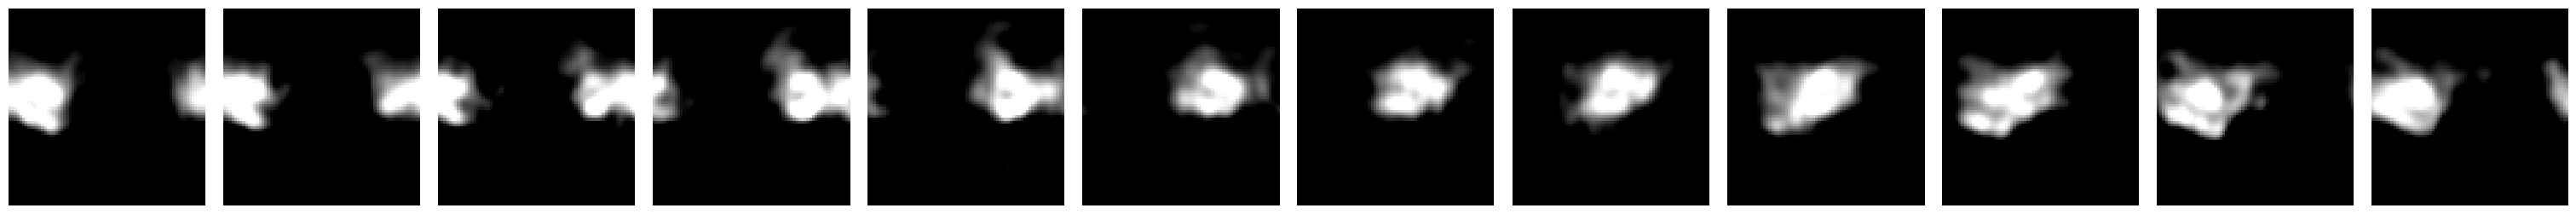

In [29]:
from openstl.utils import show_video_line

# show the given frames from an example
inputs = np.load('./work_dirs/custom_exp/saved/inputs.npy')
preds = np.load('./work_dirs/custom_exp/saved/preds.npy')
trues = np.load('./work_dirs/custom_exp/saved/trues.npy')

example_idx = 0
show_video_line(trues[example_idx], ncols=aft_seq_length, vmax=vmax, cbar=False, out_path=None, format='png', use_rgb=True)

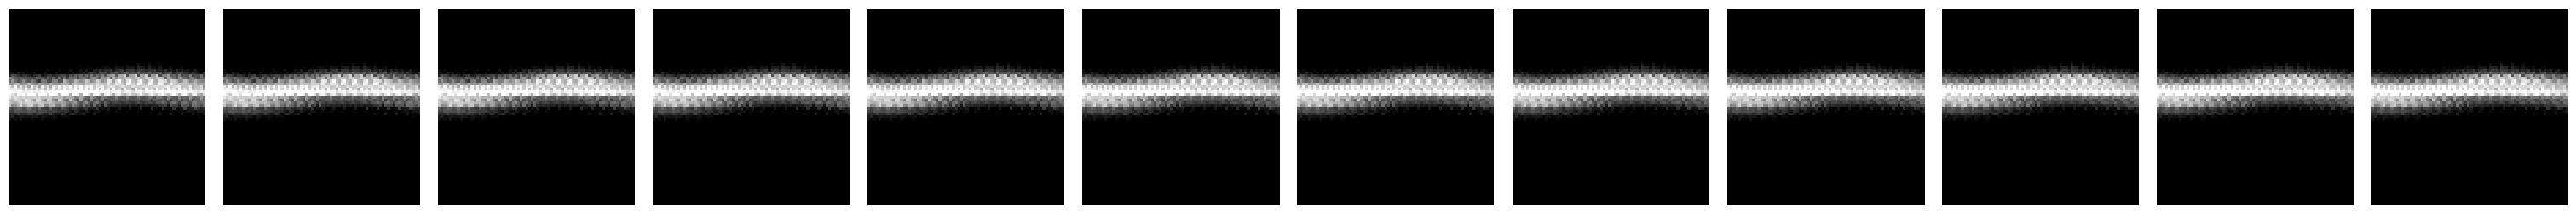

In [31]:
example_idx = 0
show_video_line(preds[example_idx], ncols=aft_seq_length, vmax=vmax, cbar=False, out_path=None, format='png', use_rgb=True)

### Generate a GIF

In [33]:
!pwd

/content/OpenSTL


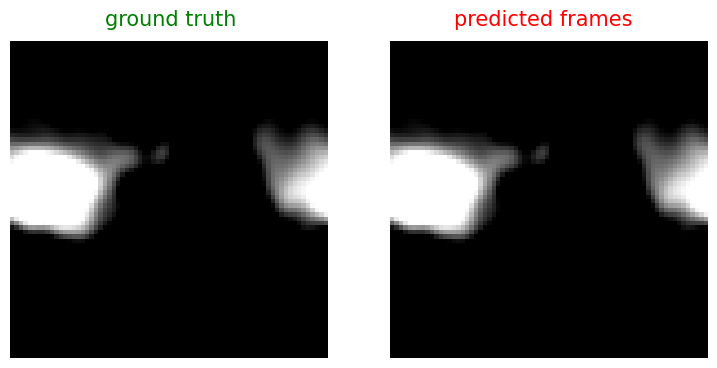

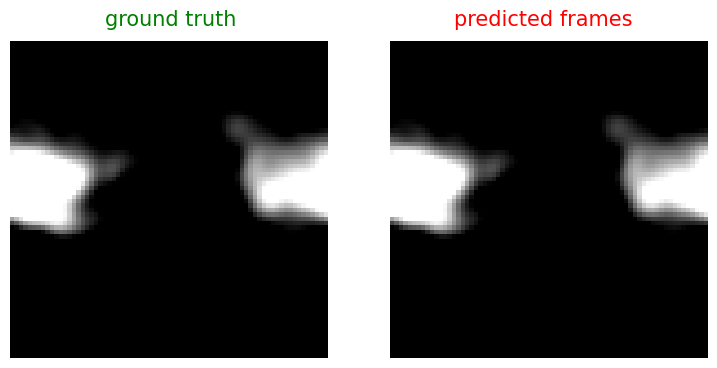

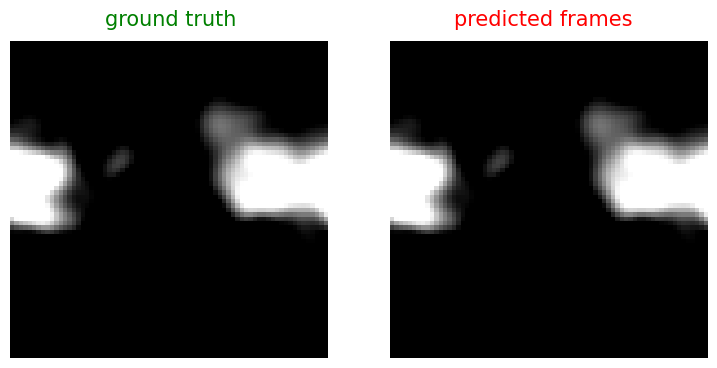

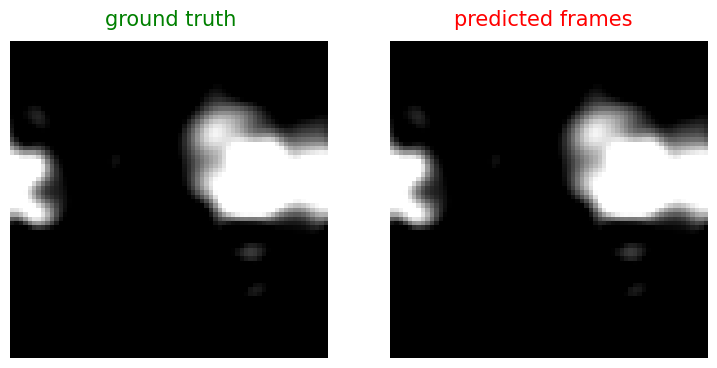

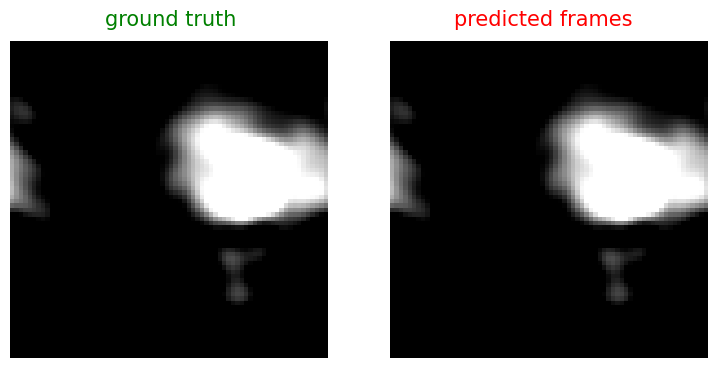

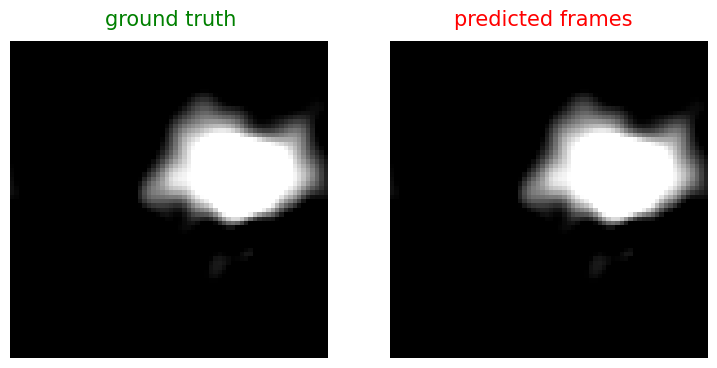

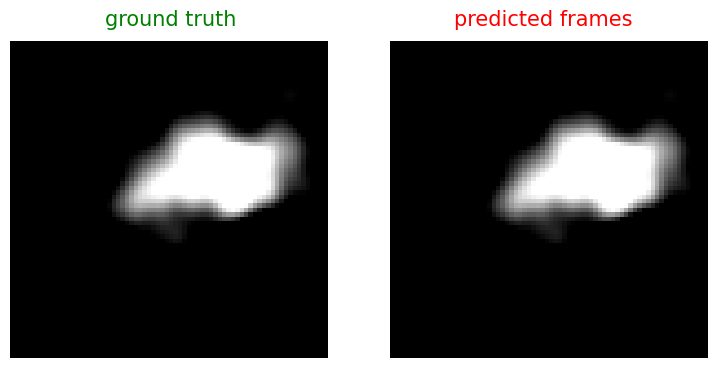

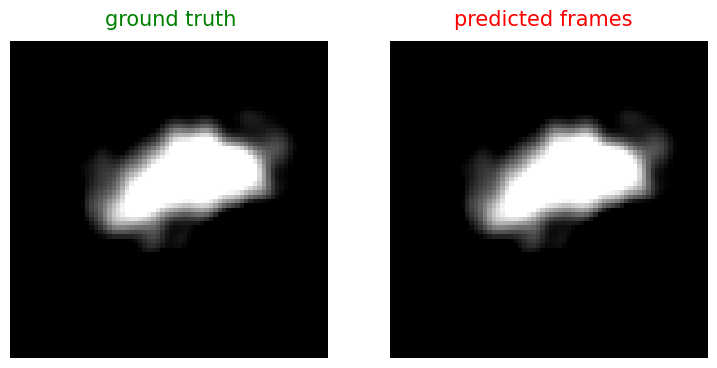

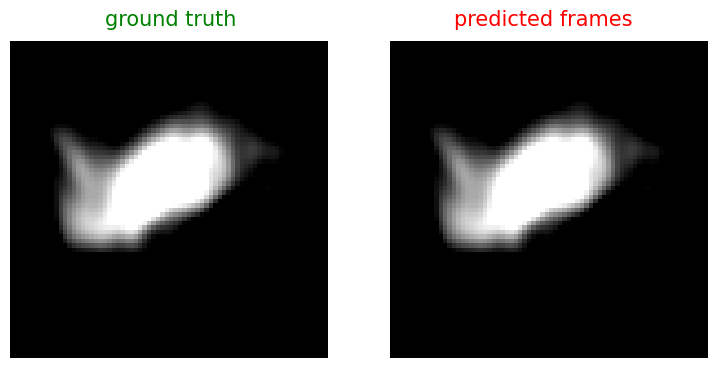

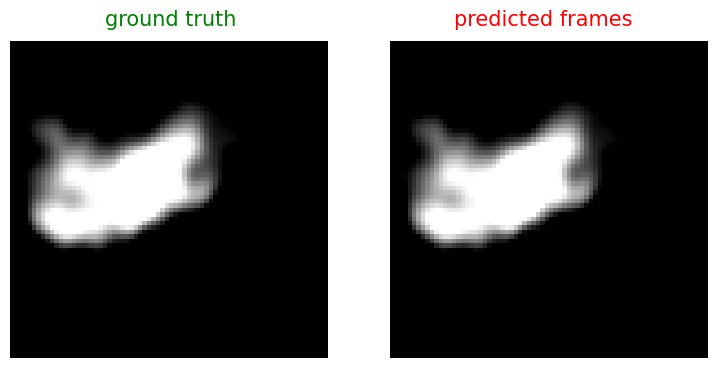

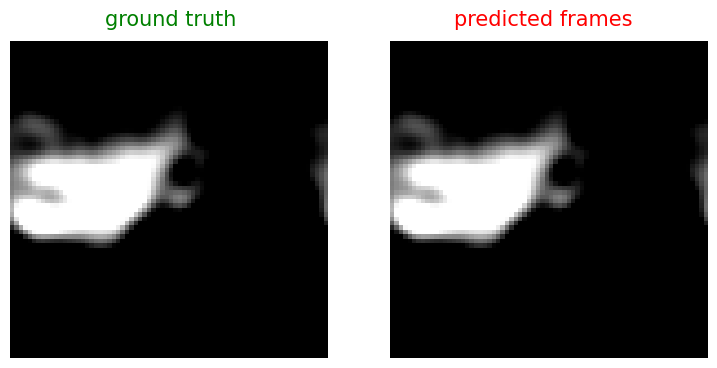

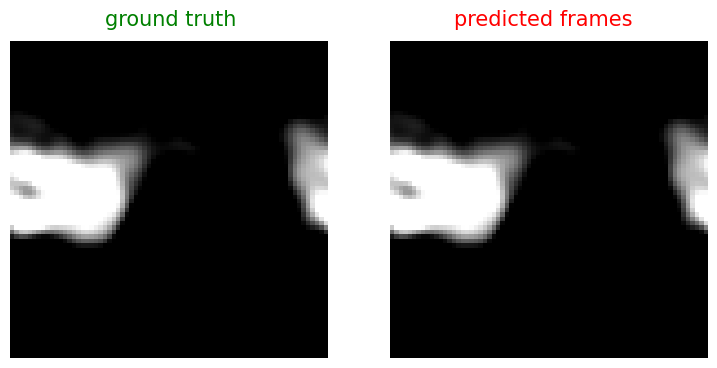

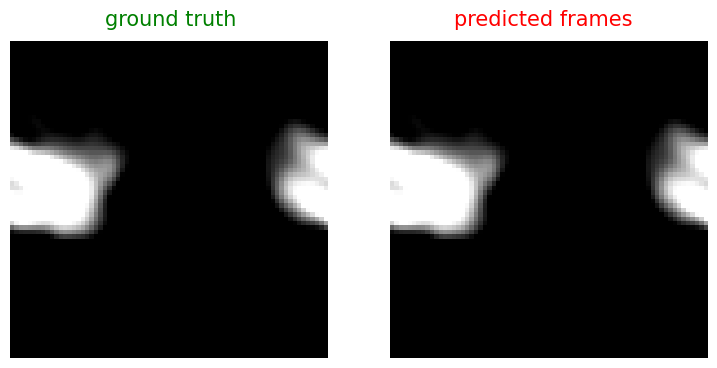

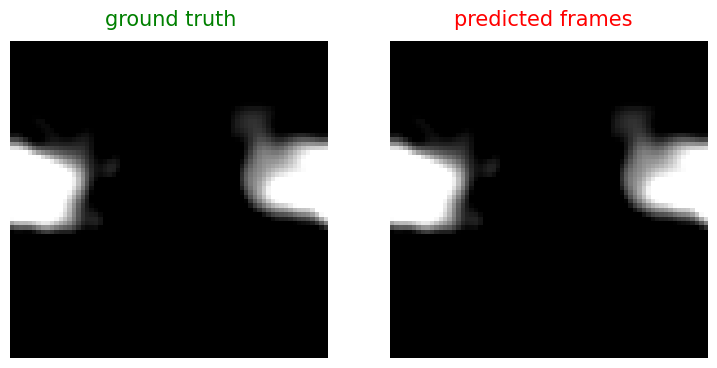

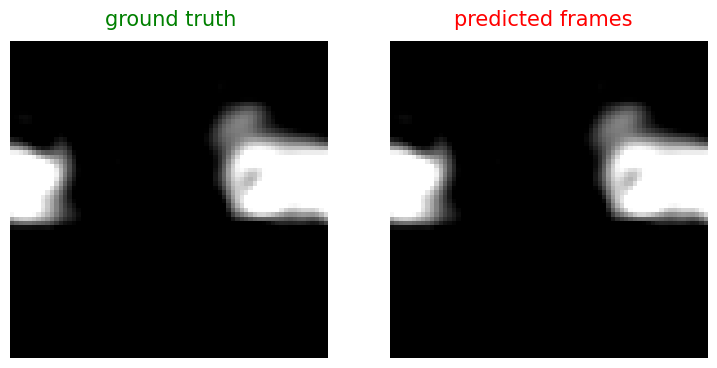

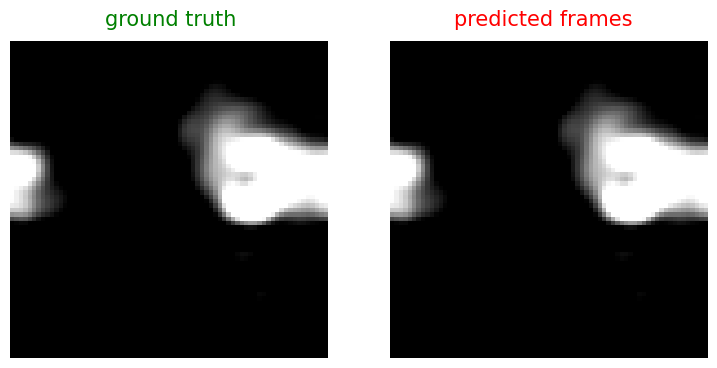

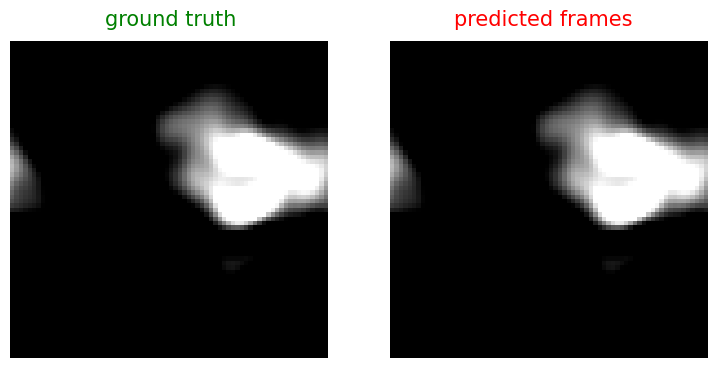

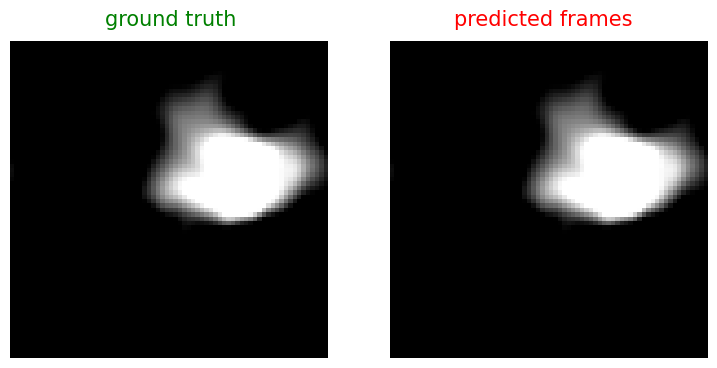

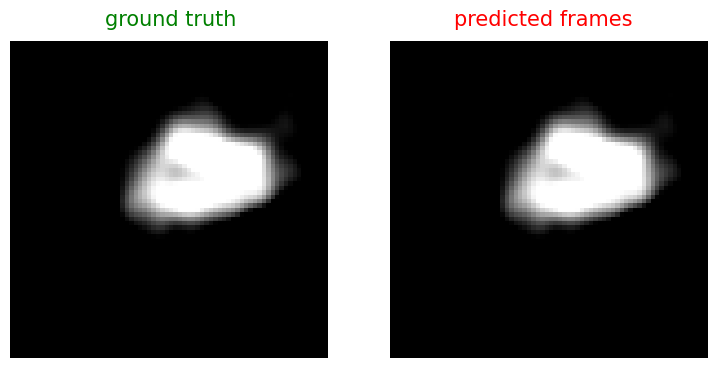

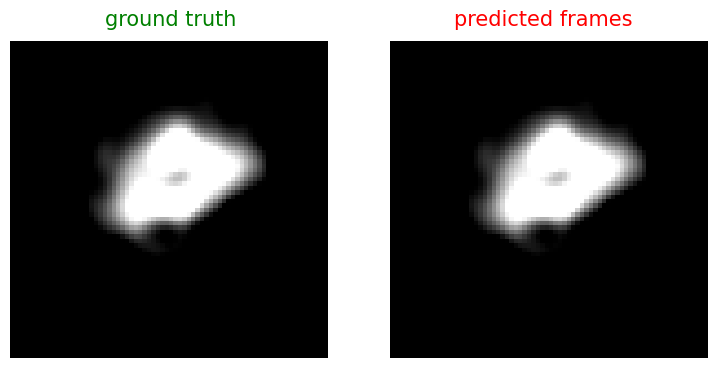

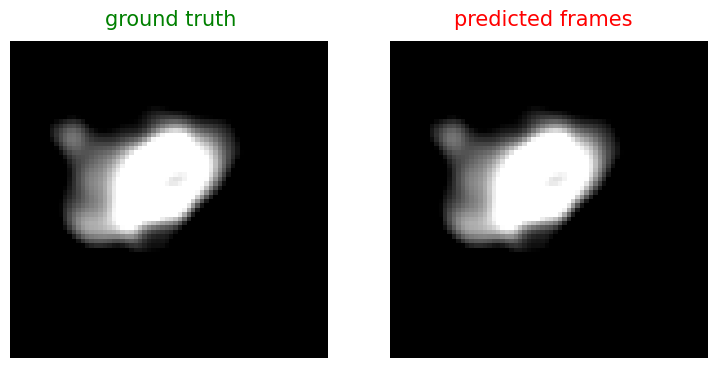

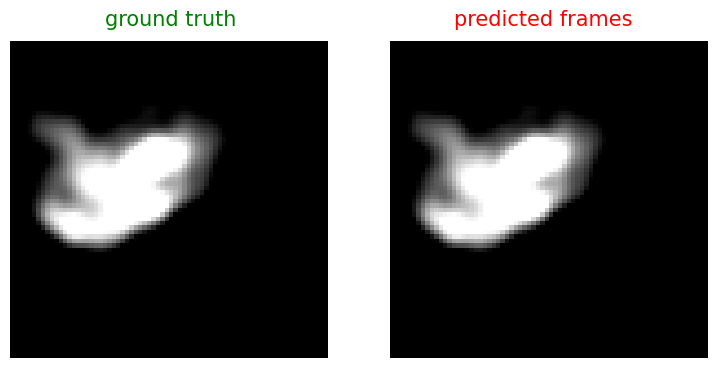

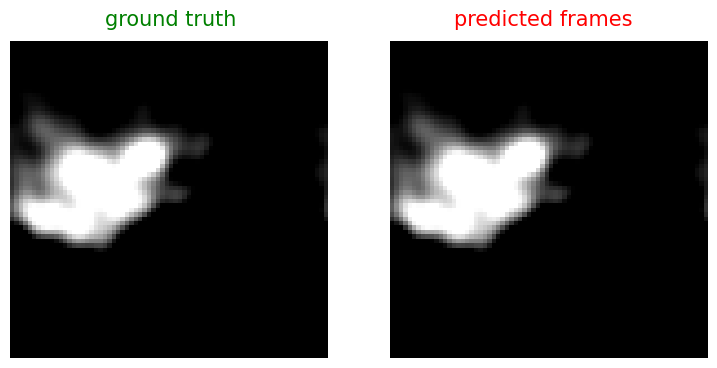

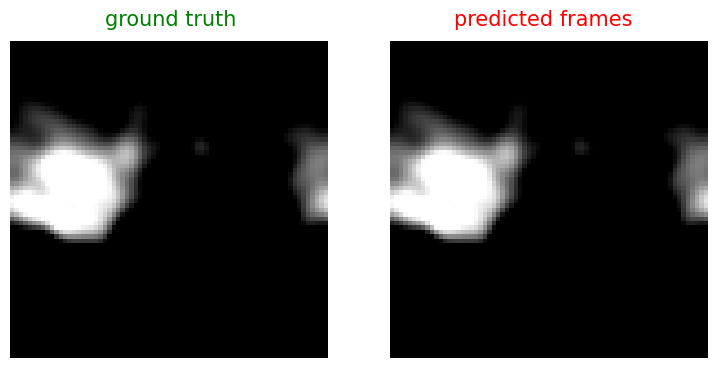

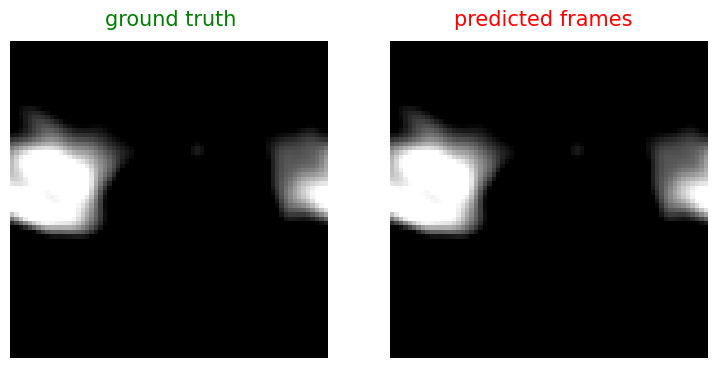

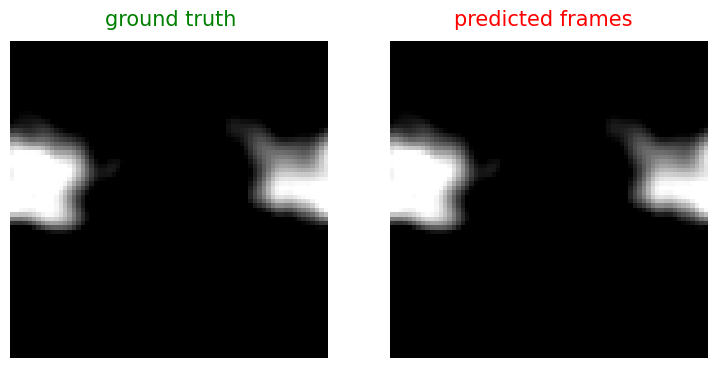

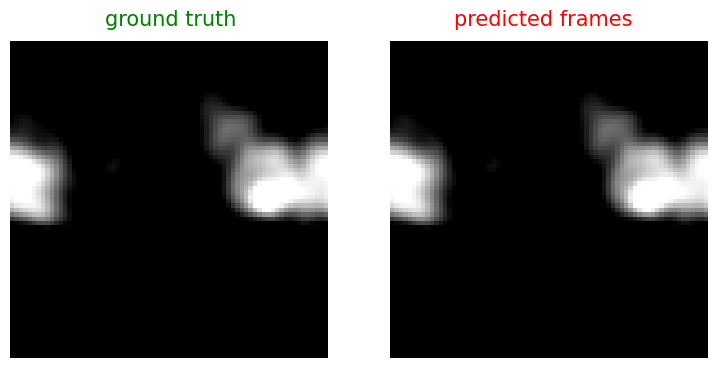

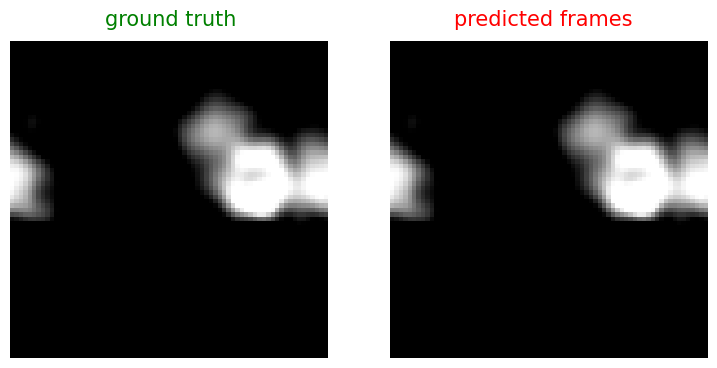

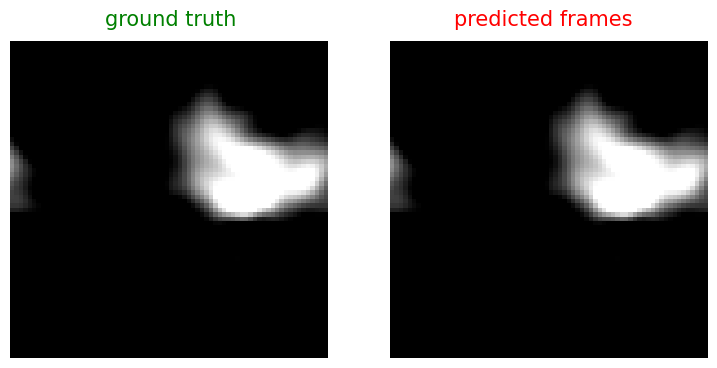

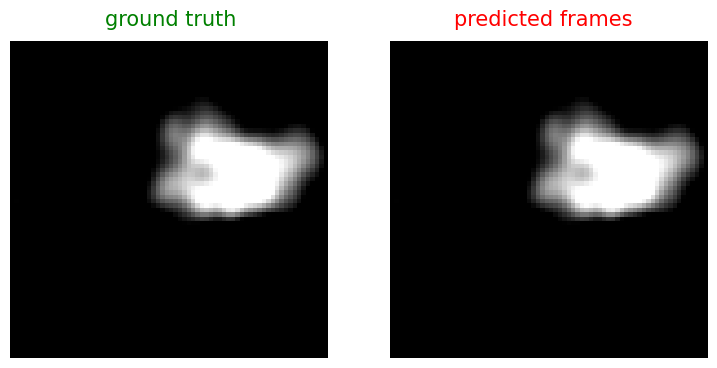

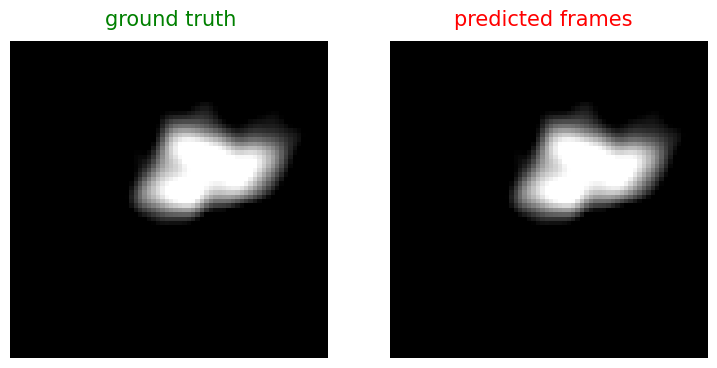

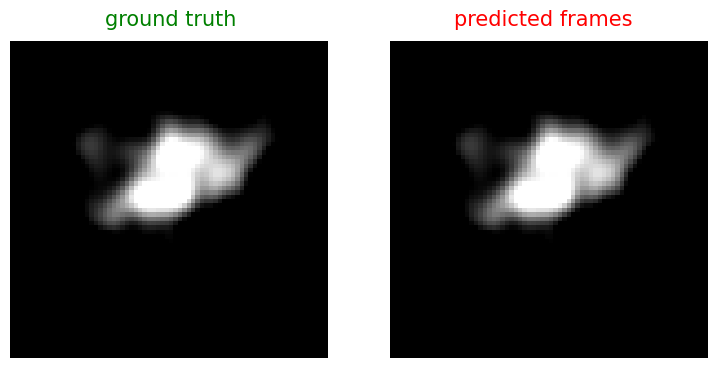

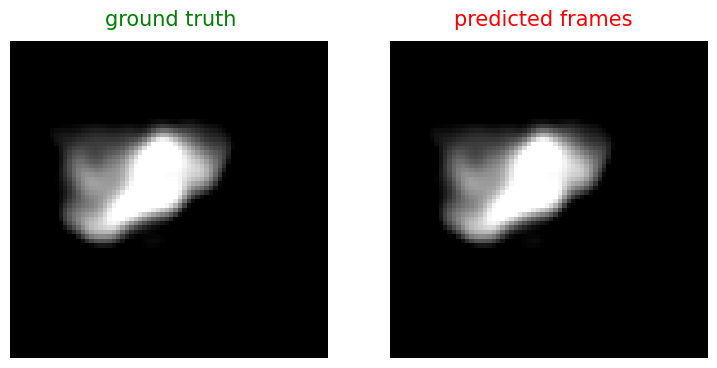

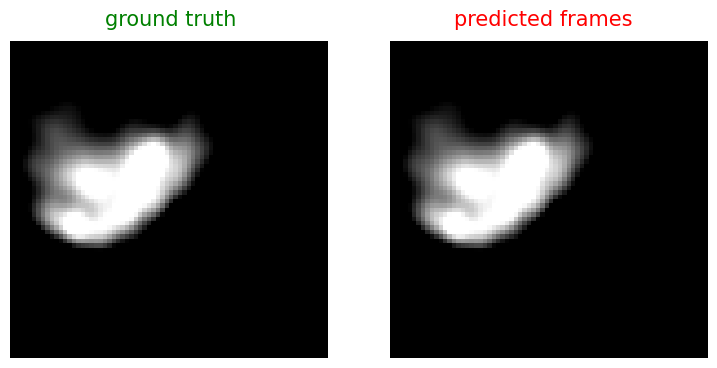

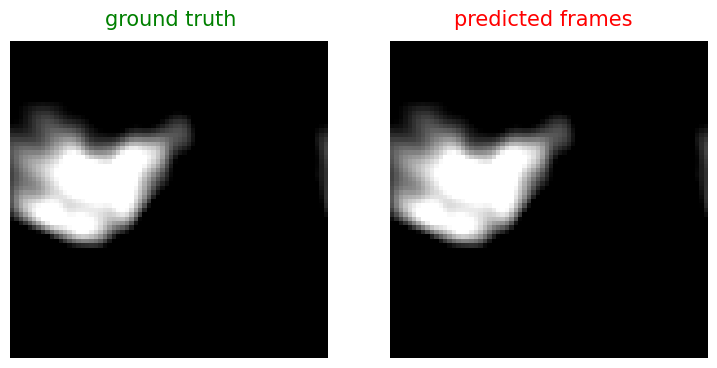

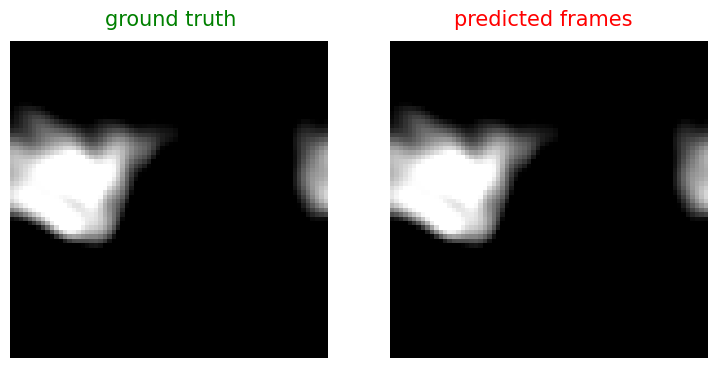

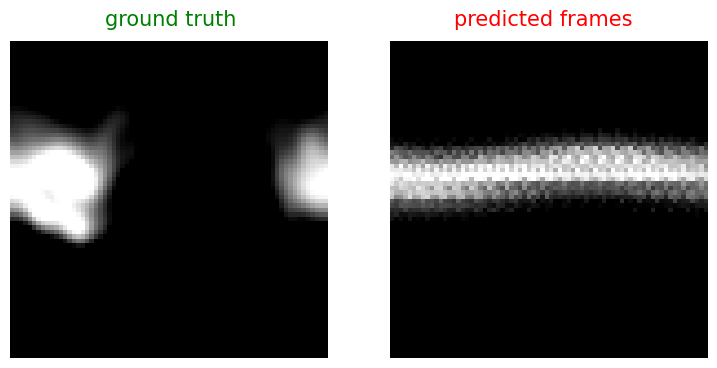

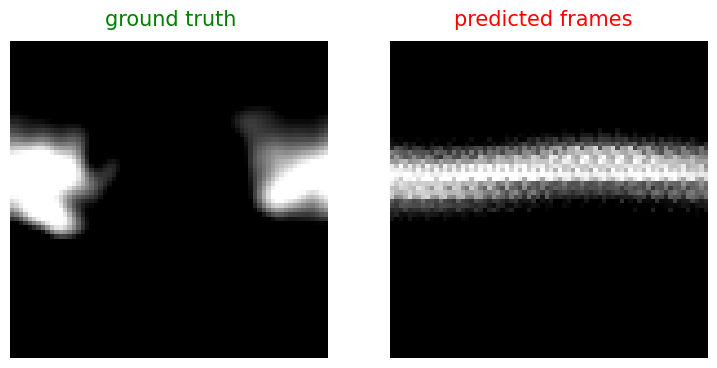

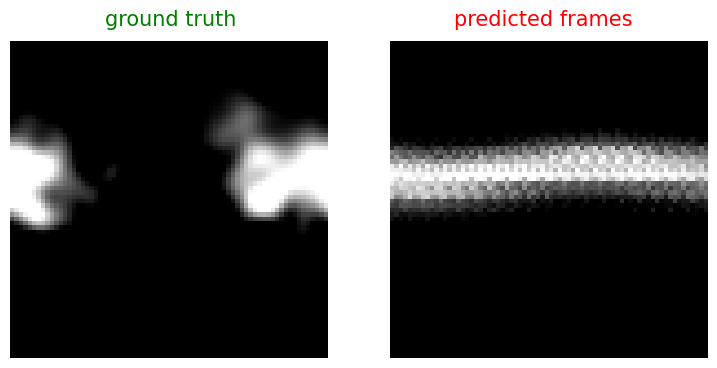

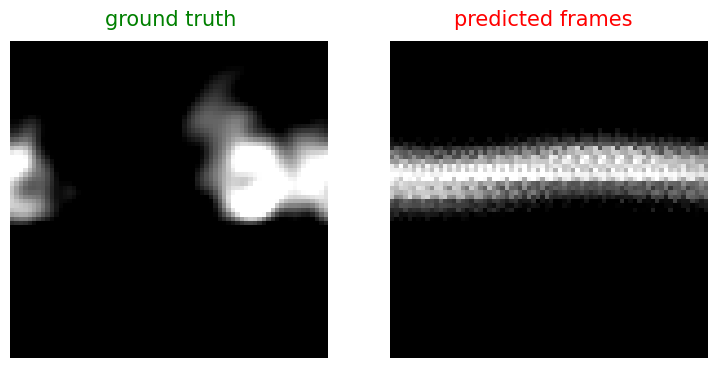

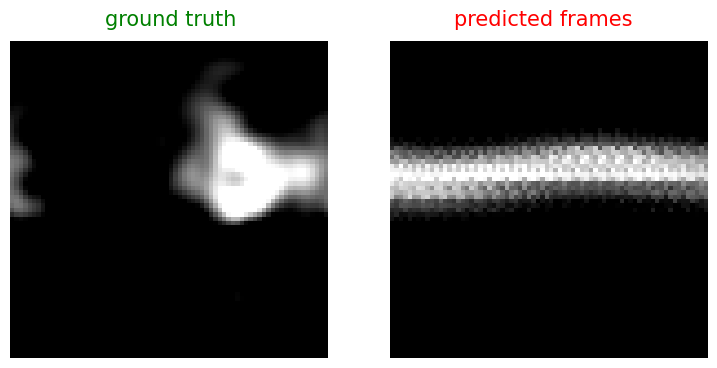

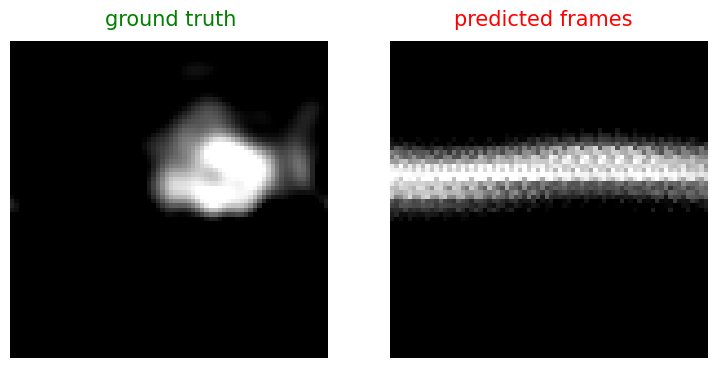

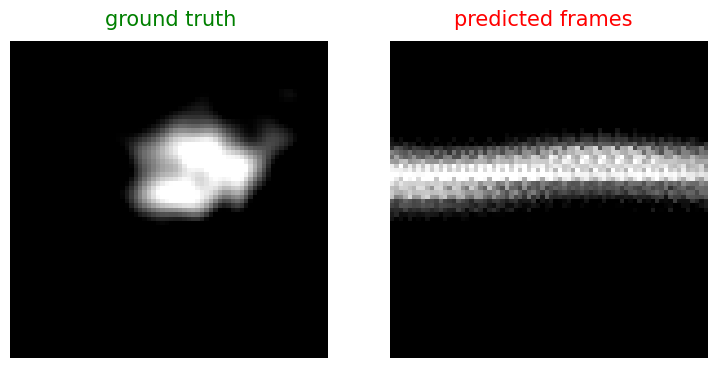

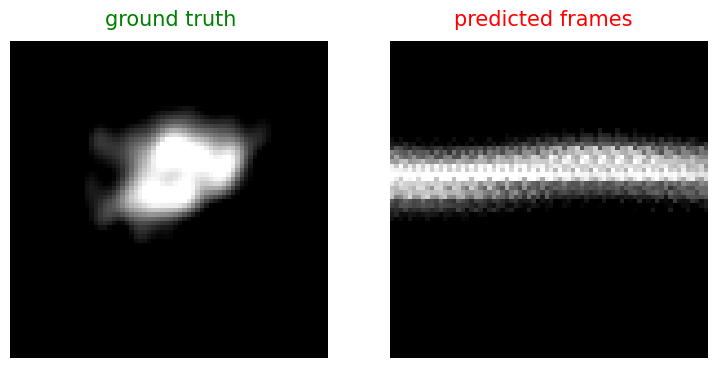

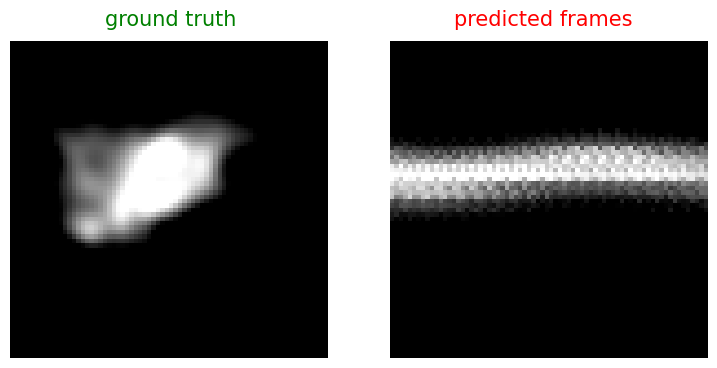

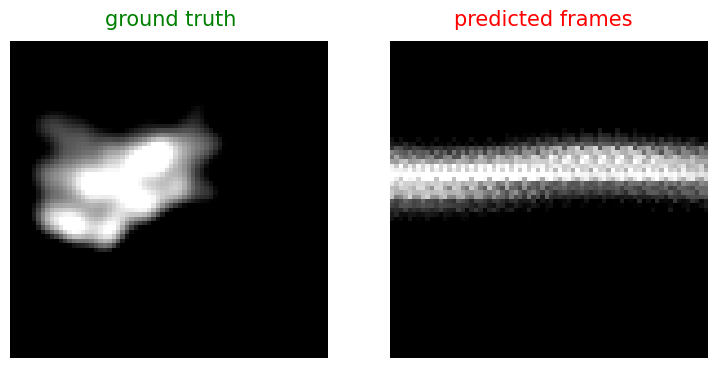

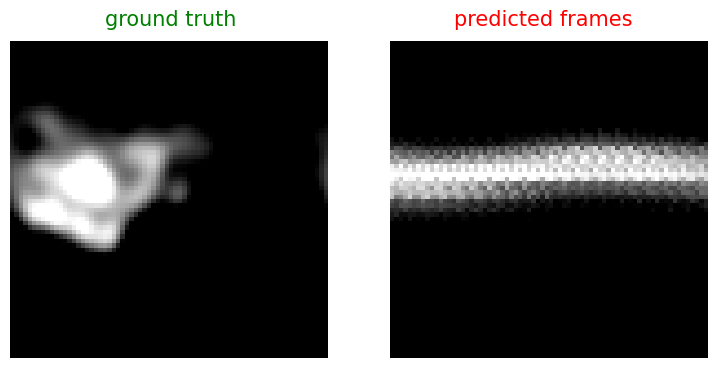

In [32]:
from openstl.utils import show_video_gif_multiple

example_idx = 0
show_video_gif_multiple(inputs[example_idx], trues[example_idx], preds[example_idx], use_rgb=True, out_path='example.gif')

# Checking metrics in TECU

In [35]:
#Multiplying the difference by the std deviation of the dataset to get the difference in TEC units.
difference=(preds-trues)*ionexTestData.std.flatten()[0]
mae=(np.mean(np.abs(difference)))
rmse=(np.sqrt(np.mean(difference**2)))
print(f"MAE: {mae}, RMSE: {rmse}")

MAE: 8.489121437072754, RMSE: 12.04231071472168


In [ ]:
sample=0
frame=11
plt.imshow(np.moveaxis(preds[sample,frame], 0,2), extent=[-180,180,-90,90])

# Exporting a GIF

In [ ]:
import imageio
from IPython.display import Image

#NOT WORKING
def saveGif(matrixList, gifFileName):
    imageio.mimwrite(gifFileName,(matrixList*256).astype(np.uint8))

In [ ]:
#NOT WORKING
t=0
fname=f'pred{t}.gif''
saveGif(preds[t],fname)
Image(open(fname,'rb').read())